## Jupyter Notebook - Trabajo Final - Análisis a nivel municipal de Puntajes ICFES
##### Integrantes:
Miranda Niño,
Andrés Serrano,
Juan C. Arévalo

### Contexto:
El siguiente es un jupyter notebook que le permitirá analizar la relación entre los puntajes ICFES con los principales indicadores de un municipio. El código le permitirá entender poco a poco cómo se hace la limpieza de las bases de datos, se construyen unos modelos predictivos sencillos y, a partir de los resultados obtenidos, poderlos ver gráficamente. Al final, el instructivo incluirá ejercicios adicionales para profundizar el análisis de la relación para el año 2022.

### Sección 1: Contexto y Motivación
XXXXXXX

### Sección 2: Manejo de los Datos

Para este análisis de puntaje, vamos a consultar los principales datos de educación y de categorías generales de los municipios de la siguiente forma:
1. Resultados de puntajes Saber 11: Encontrados directamente en la página del ICFES - DataICFES: (https://www.icfes.gov.co/investigaciones/data-icfes/). Para el ejercicio tomaremos la base anual 2022
2. Encuesta de Calidad de Vida (ECV): Encontrada directamente en el repositorio del DANE - ANDA: (https://microdatos.dane.gov.co/index.php/catalog/793). De la misma forma, para el ejercicio tomaremos la base anual 2022.
3. Shapefile del país: Encontrado en el Geoportal del DANE: (https://www.dane.gov.co/files/geoportal-provisional/).

A partir de estos datos, podemos empezar a hacer la limpieza y el orden respectivo: 

#### 2.1. Limpieza de datos del ICFES:
Em primer lugar, se deben descargar los datos correspondientes al ICFES. La descarga es una descarga manual. Para realizarla:
1.  Diríjase al link que está en la parte superior. 
2. Allí, deberá registrarse para poder acceder a las bases públicas. Debe seleccionar la base de la prueba Saber 11 en el formulario.
3. Después de enviado el registro, le llegará al correo electrónico un link para poder acceder a las bases de datos.
4. El link lo redirigirá al diccionario de datos del examen Saber 11. En la página 3, busque la opción "Bases a Nivel Nacional".
5. La opción lo llevará a un Sharepoint público del ICFES. En él, están todos los archivos (en formato .txt) desde el año 1996.
6. Descargue los archivos "Examen_Saber_11_20221.txt" (que corresponde al primer semestre) y "Examen_Saber_11_20222.txt" (para el segundo semestre).

Los datos nacionales de los puntajes del Saber 11 provenientes del ICFES están separados según fecha de presentación. Es decir, para analizar el año 2022 tenemos los resultados del primer y segundo semestre por separado. Antes de hacer cualquier análisis, primero se deben unir y limpiar estas bases de datos:

- Sugerencia: Defina una carpeta dentro de su entorno de trabajo para la programación, luego, construya una subcarpeta que se llame "Datos" y, dentro de ella, incluya todos los archivos que vaya descargando.

Con los datos descargados, se procede a importarlos dentro del entorno. El código está decodificado para trabajar esos archivos. Simplemente ajuste la ruta de cada uno de los archivos como indican los comentarios del código:

In [13]:
# Utilizamos el paquete pandas para hacer el manejo de los datos:
import pandas as pd

# Coloque aquí la ruta donde acomodará los datos del ICFES 1er semestre:
ruta_icfes1 = r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\Examen_Saber_11_20221.txt"

# Coloque aquí la ruta donde acomodará los datos del ICFES 2do semestre:
ruta_icfes2 = r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\Examen_Saber_11_20222.txt"

# Luego, se realiza la carga de los archivos:
df_s1 = pd.read_csv(ruta_icfes1, sep=';', low_memory=False)
df_s2 = pd.read_csv(ruta_icfes2, sep=';', low_memory=False)

# Revisemos el tamaño de ambas bases de datos:
print(f"Para el 2022 - Semestre 1, se tienen {len(df_s1):,} filas y {df_s1.shape[1]} columnas.")
print(f"Para el 2022 - Semestre 2, se tienen {len(df_s2):,} filas y {df_s2.shape[1]} columnas.")

Para el 2022 - Semestre 1, se tienen 73,795 filas y 84 columnas.
Para el 2022 - Semestre 2, se tienen 589,183 filas y 84 columnas.


Los datos muestran que, para el año 2022, hubo un total de 622.978 estudiantes que presentaron las pruebas Saber 11 a nivel nacional. Sin embargo, este dato está "en crudo" y necesita hacerse la limpieza respectiva. Para ello, ejecutamos el siguiente código:

In [4]:
# Antes de continuar, hay que verificar que las celdas coincidan, es un buen procedimiento para confirmar que manejamos las mismas columnas a lo largo de los datasets:
cols_s1 = set(df_s1.columns)
cols_s2 = set(df_s2.columns)

if cols_s1 == cols_s2:
    print(" Las columnas son idénticas en ambos semestres")
else:
    print("Columnas en S1 pero no en S2:", cols_s1 - cols_s2)
    print("Columnas en S2 pero no en S1:", cols_s2 - cols_s1)

 Las columnas son idénticas en ambos semestres


El anterior proceso ya nos confirma que, tal como lo menciona el ICFES, los datos mantienen la misma estructura a lo largo de los años y, por tanto, podemos limpiarlos y juntarlos en un único dataset que va a ser nuestro dataset anual. Para ello, ejecutamos el siguiente código donde se van a unir ambos dataset con la función .concat, se van a eliminar datos que parezcan atípicos como puntajes negativos o datos de municipios en blanco y se van a buscar y eliminar estudiantes duplicados (suponiendo que hay estudiantes que volvieron a presentarse a las pruebas):

In [5]:
#Utilizamos el siguiente comando para hacer el pegue de los datasets:
df_2022 = pd.concat([df_s1, df_s2], ignore_index=True)

print(f"Total filas unidas: {len(df_2022):,}")
print(f"Períodos presentes: {df_2022['periodo'].unique()}")

# Dentro de la limpieza, debemos verificar si hay duplicados por estudiante:
duplicados = df_2022.duplicated(subset='estu_consecutivo').sum()
print(f"Estudiantes duplicados: {duplicados:,}")

# Hacemos limpieza preliminar:
df_2022_limpio = df_2022[
    df_2022['cole_mcpio_ubicacion'].notna() &  # con municipio
    (df_2022['punt_global'] > 0)               # puntaje válido
].copy()

# Procedemos a eliminar los duplicados:
df_2022_limpio = df_2022_limpio.drop_duplicates(subset='estu_consecutivo', keep='first')

# Imprimimos la visión general de los resultados:
print(f"\nFilas después de limpieza: {len(df_2022_limpio):,}")
print(f"Municipios únicos: {df_2022_limpio['cole_mcpio_ubicacion'].nunique()}")
print(f"Estudiantes duplicados restantes: {df_2022_limpio.duplicated(subset='estu_consecutivo').sum()}")

Total filas unidas: 662,978
Períodos presentes: [20221 20222]
Estudiantes duplicados: 0

Filas después de limpieza: 563,755
Municipios únicos: 1031
Estudiantes duplicados restantes: 0


Este resultado, a nivel económico, ya nos da una primer observación: Después de hacer una limpieza de duplicados y valores atípicos, para los dos semestres del año 2022 se cuentan con 563.755 observaciones que son únicas. Es decir, representan a estudiantes que presentaron el examen Saber 11 una única vez durante ese año. Además, estos datos representan a 1031 municipios, con lo cual tenemos cubierto casi todo el territorio nacional, sin pérdida de generalidad. Esto es muy importante ya que podemos verificar los resultados en casi todos los municipios y, de forma agregada, en los departamentos del país.

El resultado anterior ya nos permitió ver resultados de forma individual. Sin embargo, queremos tener agrupados datos a nivel municipal. Por ello, haremos la agrupación de los datos usando la función .groupby, usando el código del municipio que incluye la base. Además, se van a mantener ciertas características de las bases originales:
* Se van a contar el total de estudiantes que presentaron el examen durante el año 2022.
* Se van a obtener los promedios de los puntajes totales y de las áreas evaluadas (matemáticas, lectura, sociales, ciencias naturales e inglés).
* Se van a crear porcentajes, usando las características de los hogares, de la proporción de estudiantes que tienen acceso a internet y computador.
* Por último, se van a crear los porcentajes de padres de los estudiantes que tienen educación superior completa y una variable que mide el porcentaje de las familias que creen que su situación económica está mejor.

Estos resultados se van a imprimir usando el método .describe()

In [15]:
# Hacemos una agrupación general por municipio
municipios_2022 = df_2022_limpio.groupby(
    ['cole_cod_mcpio_ubicacion', 'cole_mcpio_ubicacion', 'cole_depto_ubicacion']
).agg(
    num_estudiantes      = ('punt_global', 'count'),
    punt_global_prom     = ('punt_global', 'mean'),
    punt_mate_prom       = ('punt_matematicas', 'mean'),
    punt_lect_prom       = ('punt_lectura_critica', 'mean'),
    punt_nat_prom        = ('punt_c_naturales', 'mean'),
    punt_soc_prom        = ('punt_sociales_ciudadanas', 'mean'),
    punt_ingles_prom     = ('punt_ingles', 'mean'),
    pct_internet         = ('fami_tieneinternet',
                            lambda x: (x == 'Si').sum() / x.notna().sum()),
    pct_computador       = ('fami_tienecomputador',
                            lambda x: (x == 'Si').sum() / x.notna().sum()),
    pct_educ_madre_sup   = ('fami_educacionmadre',
                            lambda x: x.isin([
                                'Educación profesional completa',
                                'Postgrado']).sum() / x.notna().sum()),
    pct_educ_padre_sup   = ('fami_educacionpadre',
                            lambda x: x.isin([
                                'Educación profesional completa',
                                'Postgrado']).sum() / x.notna().sum()),
    pct_sit_eco_mejor  = ('fami_situacioneconomica',
                          lambda x: (x == 'Mejor').sum() / x.notna().sum()),
).reset_index()

# Por cuestiones de limpieza de los promedios, los vamos a redondear a 3 decimales:
municipios_2022 = municipios_2022.round(3)

# Imprimimos unos resultados para ver los datos:
print(municipios_2022.describe())

       cole_cod_mcpio_ubicacion  num_estudiantes  punt_global_prom  \
count               1114.000000      1114.000000       1114.000000   
mean               38254.168761       506.063734        237.978130   
std                26189.140280      2896.888691         21.432969   
min                 5001.000000         6.000000        169.318000   
25%                15668.500000        65.000000        223.488500   
50%                25811.000000       135.500000        239.770000   
75%                66084.750000       304.000000        252.788750   
max                99773.000000     83069.000000        306.266000   

       punt_mate_prom  punt_lect_prom  punt_nat_prom  punt_soc_prom  \
count     1114.000000     1114.000000    1114.000000    1114.000000   
mean        48.539684       50.038544      47.147100      45.238724   
std          5.218270        4.074581       4.027532       4.194258   
min         29.818000       35.500000      35.108000      32.600000   
25%         45

De manera general, podemos observar que, para 1114 municipios, el promedio de estudiantes que presentaron el Saber 11 por municipio es de 506 estudiantes. De ellos, el puntaje promedio ronda los 237 y se ve que los puntajes por áreas se acercan a los 50 puntos, siendo sociales el de peor rendimiento (aunque por una diferencia mínima). Además, en el país el 52% de los estudiantes tienen acceso a internet en sus hogares y, aun peor, solamente el 36% de ellos pueden acceder a un computador en su hogar.

Esto, de forma muy preliminar, ya va dando indicios de que no todos los estudiantes pueden competir en las mismas condiciones y sin poder acceder al mismo conocimiento. Sin embargo, necesitamos de más datos para poder construir un modelo completo

#### 2.2. Limpieza de datos de la ECV - DANE

Después de revisar los datos que nos proveen los resultados de las Pruebas Saber 11, cambiamos a obtener información de la Encuesta de Calidad de Vida del DANE para el año 2022. Esta encuesta recoge información importante sobre las condiciones de vivienda, salud, educación y trabajo de las familias colombianas. Para acceder a ella, se procede a hacer la siguiente descarga manual:
1. Diríjase al link que está en la introducción de la sección.
2. Seleccione la pestaña "Obtener Microdatos".
3. Descargue las bases de datos que considere necesarias. Para este primer ejercicio, descargue "Datos de la vivienda", "Fuerza de trabajo" y "Municipio de aplicación de la encuesta 2022".

* Sugerencia: Pegue los datos que descarga en la misma carpeta donde viene trabajando los del ICFES. Así, puede tener un mejor orden del entorno de trabajo.

Con las bases ya descargadas, podemos hacer el respectivo proceso de limpieza de estas bases. A continuación, pegue la ruta donde se encuentran cada uno de los archivos que acabó de descargar:

In [20]:
# Primero, pegue aquí la ruta donde se encuentra el archivo de datos de la vivienda:

ruta_daneviv = r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\Datos de la vivienda.CSV"

# Luego, pegue aquí la ruta donde se encuentra el archivo de fuerza de trabajo:
ruta_danelab = r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\Fuerza de trabajo.CSV"

# Por último, pegue aquí la ruta donde se encuentra el archivo auxiliar de municipios:
ruta_danemun = r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\Municipio de aplicación de la encuesta.CSV"


# Ahora, podemos proceder a importar las bases de datos:
df_vivienda   = pd.read_csv(ruta_daneviv, sep=";", low_memory=False)
df_trabajo    = pd.read_csv(ruta_danelab, sep= ";", low_memory=False)
df_municipios = pd.read_csv(ruta_danemun, sep= ";", low_memory=False)

# Para comenzar, miremos la estructura inicial de los datos de vivienda

print(f"Dimensiones: {df_vivienda.shape}")
print(f"Estadísticas Descriptivas:\n{df_vivienda.describe()}")

Dimensiones: (87878, 48)
Estadísticas Descriptivas:
         DIRECTORIO  SECUENCIA_ENCUESTA  SECUENCIA_P    ORDEN  \
count  8.787800e+04             87878.0      87878.0  87878.0   
mean   7.848730e+06                 1.0          1.0      1.0   
std    3.369144e+04                 0.0          0.0      0.0   
min    7.787900e+06                 1.0          1.0      1.0   
25%    7.821291e+06                 1.0          1.0      1.0   
50%    7.848838e+06                 1.0          1.0      1.0   
75%    7.876507e+06                 1.0          1.0      1.0   
max    7.910108e+06                 1.0          1.0      1.0   

       P1_DEPARTAMENTO        REGION         CLASE         FEX_C  \
count     87878.000000  87878.000000  87878.000000  87878.000000   
mean         48.467296      4.051480      1.489121    198.159528   
std          30.097632      2.923974      0.499884    327.556512   
min           5.000000      1.000000      1.000000      1.599729   
25%          19.000000

Los datos de vivienda muestran de manera general que hay 87.878 hogares que viven en viviendas unifamiliares. Repetimos el proceso con los datos de fuerza laboral:

In [21]:
#Estadísticas descriptivas de la fuerza laboral:
print(f"Dimensiones: {df_trabajo.shape}")
print(f"Estadísticas Descriptivas:\n{df_trabajo.describe()}")

Dimensiones: (204636, 97)
Estadísticas Descriptivas:
         DIRECTORIO  SECUENCIA_ENCUESTA    SECUENCIA_P          ORDEN  \
count  2.046360e+05       204636.000000  204636.000000  204636.000000   
mean   7.848432e+06            1.988115       1.005092       1.988115   
std    3.371733e+04            1.201003       0.082615       1.201003   
min    7.787900e+06            1.000000       1.000000       1.000000   
25%    7.821068e+06            1.000000       1.000000       1.000000   
50%    7.848395e+06            2.000000       1.000000       2.000000   
75%    7.876040e+06            2.000000       1.000000       2.000000   
max    7.910108e+06           29.000000       5.000000      29.000000   

               FEX_C          P6230          P6240          P6250  \
count  204636.000000  204636.000000  204636.000000  103491.000000   
mean      206.733218       1.815423       2.505952       1.926912   
std       337.024921       1.109195       1.515010       0.260283   
min         1

Ahora sí, después de entender de forma general la estructura de los datos, se procede a hacer la unión. Con ello, vamos a juntar las bases de datos con la llave municipal que brinda el DANE, la cual une a cada directorio con un código de municipio y, después de hacer el merge usando la función .merge(), podemos agregar todas nuestras variables de interés por municipio.

Primero, vamos a unir las llaves de agregación:

In [23]:
# Unimos la llave al df de los datos de la vivienda:
df_vivienda_merged = df_vivienda.merge(
    df_municipios.rename(columns={'directorio': 'DIRECTORIO'}),
    on='DIRECTORIO', how='left'
)

#Verificamos que la unión haya quedado bien:
print(f"Vivienda con municipio: {len(df_vivienda_merged):,} filas")
print(f"Sin municipio: {df_vivienda_merged['P1_MUNICIPIO'].isnull().sum():,}")

#Luego, unimos la llave al df de los datos de la fuerza laboral:
df_trabajo_merged = df_trabajo.merge(
    df_municipios.rename(columns={'directorio': 'DIRECTORIO'}),
    on='DIRECTORIO', how='left'
)

#Verificamos que la unión haya quedado bien:
print(f"Vivienda con municipio: {len(df_trabajo_merged):,} filas")
print(f"Sin municipio: {df_trabajo_merged['P1_MUNICIPIO'].isnull().sum():,}")

Vivienda con municipio: 87,878 filas
Sin municipio: 0
Vivienda con municipio: 204,636 filas
Sin municipio: 0


La verificación nos debe mostrar que todas las viviendas referenciadas en la encuesta deben estar asociadas a un municipio (confirmado porque para ambos casos hay 0 viviendas sin municipio asociado).

Con la confirmación, podemos proceder a agregar por municipio usando la función .groupby() y seleccionando las siguientes que son las principales variables del modelo a estimar:
* P8520S5: Variable dummy que toma el valor de 1 si la vivienda tiene acceso al acueducto, 0 si no.
* P8520S3: Variable dummy que toma el valor de 1 si la vivienda tiene acceso al alcantarillado, 0 si no.
* P8520S1: Variable dummy que toma el valor de 1 si la vivienda tiene acceso a energía eléctrica, 0 si no.

A estas variables, usando la función .agg(), las vamos a convertir a proporciones, para ver cuál es la proporción a nivel municipio de acceso a estos servicios públicos.

* Opcional: En este punto, puede probar un ejercicio adicional revisando en el diccionario de datos del DANE otras variables que le puedan parecer fundamentales a la hora de estimar el puntaje educativo. Lo importante es que seleccione variables nuevas y que no se encuentren en la base de datos del ICFES que ya trabajó.

In [27]:
# Creamos la agregación por municipio de las características de la vivienda:
dane_vivienda = df_vivienda_merged.groupby(
    ['P1_DEPARTAMENTO', 'P1_MUNICIPIO']
).agg(
    pct_acueducto      = ('P8520S5', lambda x: (x == 1).sum() / x.notna().sum()),
    pct_alcantarillado = ('P8520S3', lambda x: (x == 1).sum() / x.notna().sum()),
    pct_energia        = ('P8520S1', lambda x: (x == 1).sum() / x.notna().sum()),
).reset_index().round(3)

print(f"\nMunicipios en base de datos de vivienda: {len(dane_vivienda)}")
print(f"Estadísticas descriptivas: \n {dane_vivienda.describe()}")


Municipios en base de datos de vivienda: 640
Estadísticas descriptivas: 
        P1_DEPARTAMENTO  P1_MUNICIPIO  pct_acueducto  pct_alcantarillado  \
count       640.000000    640.000000     640.000000          640.000000   
mean         41.146875    421.398438       0.719392            0.420477   
std          27.126095    262.748526       0.291558            0.338992   
min           5.000000      1.000000       0.000000            0.000000   
25%          17.750000    211.250000       0.532500            0.100750   
50%          41.000000    417.500000       0.812500            0.402500   
75%          68.000000    652.250000       0.985250            0.677750   
max          99.000000    980.000000       1.000000            1.000000   

       pct_energia  
count   640.000000  
mean      0.968205  
std       0.099607  
min       0.000000  
25%       0.983000  
50%       1.000000  
75%       1.000000  
max       1.000000  


El resultado nos muestra que la encuesta de características de vivienda del DANE tiene información de 640 municipios del país. Aunque es una muestra muy representativa, hay que comentar la reducción de observaciones que se tiene. Otro de los descubrimientos que se observan es que, en promedio, el 96% de los hogares tiene acceso a energía eléctrica, siendo el servicio público más universal de los 3 analizados. Después, sigue el acueducto, con un 71% y, por último, el alcantarillado, donde menos de la mitad de la población tiene acceso a él.

Ahora, repetimos el escenario con la base de fuerza laboral, donde nos interesa tener un proxy de desempleo de las personas en el hogar. Para ello, usaremos la siguiente variable transformada:
* P6240: Variable categórica que toma los siguientes valores:
    1. Si la persona estuvo trabajando la semana inmediatamente anterior.
    2. Si la persona estuvo buscando trabajo la semana inmediatamente anterior.
    3. Si la persona estuvo estudiando la semana inmediatamente anterior.
    4. Si la persona se dedicó a los oficios del hogar la semana inmediatamente anterior.
    5. Si la persona está incapacitada permanentemente para trabajar.
    6. Si la persona realizó alguna otra actividad.

Para este caso, construiremos una Tasa de Ocupación aproximada, la cual tome la cantidad de personas contestaron P6240 = 1, sobre el total de las personas encuestadas. El procedimiento es el mismo, usamos las funciones .groupby() y .agg() para agrupar y el método .describe() para ver la forma general de la base.

In [32]:
#Agrupamos
dane_trabajo = df_trabajo_merged.groupby(
    ['P1_MUNICIPIO']
).agg(
    tasa_ocupacion = ('P6240', lambda x: (x == 1).sum() / x.notna().sum()),
).reset_index().round(4)

#Verificamos resultados:
print(f"Municipios en base de datos de trabajo:  {len(dane_trabajo)}")
print(f"Estadísticas descriptivas: \n {dane_trabajo.describe()}")


Municipios en base de datos de trabajo:  409
Estadísticas descriptivas: 
        P1_MUNICIPIO  tasa_ocupacion
count    409.000000      409.000000
mean     450.845966        0.448502
std      256.764222        0.059279
min        1.000000        0.243600
25%      235.000000        0.413800
50%      446.000000        0.453000
75%      670.000000        0.484800
max      980.000000        0.650000


El resultado nos muestra tener una población muestral menor a la que tenemos con vivienda (409 municipios). Sin embargo, el dato importante es que del total de los hogares, solamente el 44% de las personas estaban trabajando. Es decir, la gran mayoría estaban dedicados a otras actividades que, posiblemente, no le generaron ingresos al hogar.

#### 2.3. Base de Datos Final DANE (Unión ECV)
Por último, podemos proceder a hacer la unión de los datos de las dos áreas de la ECV. Para ello haremos un merge izquierdo entre las dos bases de datos que veníamos trabajando:

In [37]:
# Unir vivienda y trabajo del DANE
dane_combined = dane_vivienda.merge(
    dane_trabajo,
    on=['P1_MUNICIPIO'],
    how='left'
)

print(f"Municipios en tabla DANE combinada: {len(dane_combined)}")
print(f"Sin tasa de ocupación: {dane_combined['tasa_ocupacion'].isnull().sum()}")
print(f"\n{dane_combined.head()}")

Municipios en tabla DANE combinada: 640
Sin tasa de ocupación: 0

   P1_DEPARTAMENTO  P1_MUNICIPIO  pct_acueducto  pct_alcantarillado  \
0                5             1          0.997               0.885   
1                5             2          0.583               0.000   
2                5            45          0.932               0.689   
3                5            88          0.953               0.500   
4                5           101          1.000               0.930   

   pct_energia  tasa_ocupacion  
0          1.0          0.4785  
1          1.0          0.4514  
2          1.0          0.4763  
3          1.0          0.4836  
4          1.0          0.4894  


El resultado del merge del DANE nos da un total de 640 municipios con características socioeconómicas para poder comparar con los resultados educativos del ICFES. Sin embargo, el código del municipio y del departamento no están formateados de la misma forma en ambos, así que para la ECV, se procede a construir el código en formato DANE. 

In [ ]:
# NOTA - AYUDA DE IA: El siguiente código fue consultado con Claude para poder crear un único código para unir las bases de datos del DANE y del ICFES.

# Construir código municipio completo en dane_combined
# Formato: departamento (2 dígitos) + municipio (3 dígitos) = 5 dígitos
dane_combined['cod_municipio'] = (
    dane_combined['P1_DEPARTAMENTO'].astype(str).str.zfill(2) +
    dane_combined['P1_MUNICIPIO'].astype(str).str.zfill(3)
).astype(int)

# Verificar
print("Ejemplos de código construido:")
print(dane_combined[['P1_DEPARTAMENTO', 'P1_MUNICIPIO', 'cod_municipio']].head(10))

# Comparar con códigos del ICFES
print(f"\nEjemplos códigos ICFES:")
print(municipios_2022['cole_cod_mcpio_ubicacion'].head(10).astype(int))

Ejemplos de código construido:
   P1_DEPARTAMENTO  P1_MUNICIPIO  cod_municipio
0                5             1           5001
1                5             2           5002
2                5            45           5045
3                5            88           5088
4                5           101           5101
5                5           107           5107
6                5           129           5129
7                5           138           5138
8                5           147           5147
9                5           148           5148

Ejemplos códigos ICFES:
0    5001
1    5002
2    5004
3    5021
4    5030
5    5031
6    5034
7    5036
8    5038
9    5040
Name: cole_cod_mcpio_ubicacion, dtype: int64


#### 2.4. Unión Base de datos Final (ICFES + DANE)

Luego, con los códigos ya confirmados, procedemos a hacer un merge izquierdo entre la base de datos del ICFES y la del DANE, para obtener la base de datos final para construir el modelo.

In [39]:
# Cruce final de datos del ICFES con datos del DANE
df_final = municipios_2022.merge(
    dane_combined.drop(columns=['P1_DEPARTAMENTO', 'P1_MUNICIPIO']),
    left_on='cole_cod_mcpio_ubicacion',
    right_on='cod_municipio',
    how='left'
).drop(columns='cod_municipio')

print(f"Municipios en df_final: {len(df_final)}")
print(f"\nNulos por columna:")
print(df_final.isnull().sum())
print(f"\nPrimeras filas:")
print(df_final.head())

Municipios en df_final: 1114

Nulos por columna:
cole_cod_mcpio_ubicacion      0
cole_mcpio_ubicacion          0
cole_depto_ubicacion          0
num_estudiantes               0
punt_global_prom              0
punt_mate_prom                0
punt_lect_prom                0
punt_nat_prom                 0
punt_soc_prom                 0
punt_ingles_prom              1
pct_internet                  0
pct_computador                0
pct_educ_madre_sup            0
pct_educ_padre_sup            0
pct_sit_eco_mejor             0
pct_acueducto               478
pct_alcantarillado          478
pct_energia                 478
tasa_ocupacion              478
dtype: int64

Primeras filas:
   cole_cod_mcpio_ubicacion cole_mcpio_ubicacion cole_depto_ubicacion  \
0                    5001.0             MEDELLÍN            ANTIOQUIA   
1                    5002.0            ABEJORRAL            ANTIOQUIA   
2                    5004.0             ABRIAQUÍ            ANTIOQUIA   
3                    

El merge muestra una situación esperada. Hay 1114 municipios en total, de los cuales solo se cuenta con información del DANE para 636 de ellos (ya que es una encuesta donde se elige una muestra). Es decir, hay 478 municipios con datos nulos. Por cuestiones de no alterar los resultados con observaciones imputadas, procedemos a eliminarlas. Además, habíamos dejado pendiente un dato nulo en los puntajes de inglés del ICFES, que también procedemos a eliminar:

In [46]:
# Eliminar municipios sin datos DANE y el único nulo de inglés
df_modelo = df_final[df_final['pct_acueducto'].notna()].copy()
df_modelo = df_modelo[df_modelo['punt_ingles_prom'].notna()].copy()

#SUGERENCIA DE IA: Resetear el índice después de hacer muchos merge:
df_modelo = df_modelo.reset_index(drop=True)

#Imprimimos resultados:
print(df_modelo.describe().round(2))

       cole_cod_mcpio_ubicacion  num_estudiantes  punt_global_prom  \
count                    635.00           635.00            635.00   
mean                   41145.76           804.76            236.15   
std                    26790.65          3809.93             22.69   
min                     5001.00             9.00            170.33   
25%                    17875.00           108.00            220.84   
50%                    41016.00           231.00            237.04   
75%                    68222.00           475.00            252.22   
max                    99773.00         83069.00            306.27   

       punt_mate_prom  punt_lect_prom  punt_nat_prom  punt_soc_prom  \
count          635.00          635.00         635.00         635.00   
mean            47.93           49.78          46.80          44.87   
std              5.31            4.40           4.18           4.46   
min             31.13           36.40          35.11          32.60   
25%           

Para este punto, debemos tener una única base final (df_modelo) con 635 observaciones finales, que corresponden a municipios de Colombia. Esta base de datos iuncluye información sobre los puntajes promedio de las pruebas de estado Saber 11 para el 2022 y otros indicadores socioeconómicos de los hogares en esos municipios. La base de datos es fundamental para poder empezar a generar correlaciones en el modelo de estimación a continuación.

Para tener la base de datos limpia, la guardaremos en formato de Excel. Nos servirá en caso de volver o en caso de querer explorarla por fuera. Para ello, usaremos la función .to_excel()

In [47]:
#Exportamos el modelo a Excel:
df_modelo.to_excel(
    r"C:\Users\JUANC\Documents\2026-10 Uniandes - Python\Datos\df_modelo_2022.xlsx",
    index=False
)

#Imprimimos un mensaje de confirmación que lo guardó exitosamente:
print("Archivo guardado.")

Archivo guardado.


#### 2.5. Shapefile Municipal y Departamental

Para poder graficar y obtener mapas de Colombia, falta descargar manualmente el shapefile del país con sus formas a nivel municipal y departamental. Para ello:
1. Diríjase al link que está en la parte superior.
2. Descargue el .zip llamado "Versión MGN2025-Colombia. Todos los niveles geográficos".
3. Guarde la carpeta "**ADMINISTRATIVO"**, adentro encontrará los archivos para el shapefile municipal y departamental.

### Sección 3: Metodología y definición de modelo de estimación.

#### 3.0. Objetivo

El objetivo de esta sección es poder construir los dos modelos de estimación que nos van a permitir poder responder la pregunta problema de la cual nace este tutorial. La idea de proponer dos modelos de regresión distintos para obvservar si hay robustez de los resultados.

##### a) Modelo Regresión Múltiple:
En primer lugar, realizaremos un modelo de estimación mediante **Mínimos Cuadrados Ordinarios (MCO)**, el cual nos permite cuantificar el efecto de las principales variables socioeconómicas sobre el puntaje y determinar cuáles tienen el mayor peso explicativo. La idea central es encontrar los coeficientes $\beta_0, \beta_1, ..., \beta_k$ que minimizan la suma de errores cuadráticos entre los valores observados y los predichos por la siguiente regresión lineal:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_k x_k$$

Donde cada $\beta_i$ representa el cambio esperado en el puntaje ante un aumento unitario en la variable $x_i$, manteniendo las demás constantes. Esto nos permite no solo predecir, sino 
también interpretar qué factores tienen mayor influencia sobre el desempeño educativo municipal.

Para que los resultados sean válidos económicamente, la regresión lineal necesita algunos supuestos clave que a continuación describimos:

- **Linealidad:** Donde la relación entre las variables predictoras y el puntaje es lineal.
- **Independencia:** Las observaciones son independientes entre sí.
- **Homocedasticidad:** La varianza de los errores es constante a lo largo de los valores predichos.
- **Normalidad de los errores:** Los residuos del modelo se distribuyen estadísticamente de forma normal, aproximadamente.

En el contexto de estos datos y nuestro modelo, sabemos que se construye una relación lineal por la ecuación descrita anteriormente. Por otro lado, se trabaja de forma municipal, lo cual mitiga los problemas de heterocedasticidad del modelo y puede brindar independencia y no multicolinealidad a los resultados.

##### b) Agrupación por Clusters:
El segundo es un modelo que va a ser complementario y es un modelo de ***clustering***, donde buscamos agrupar principales variables  a nivel de los municipios según su perfil socioeconómico. Así, podemos controlar por condiciones que le aplican de forma similar a todos los habitantes de una misma región y podría generar sesgo en la estimación. 

De forma más técnica, es una forma de aprendizaje no supervisado, donde un algoritmo agrupa las observaciones según su similitud en las variables de entrada. Este modelo de control nos ayudará a determinar si el modelo principal está correctamente formulado o si el MCO tiene sesgos que no podemos ver en el primer ejercicio.



#### 3.1. Preparación de los datos con Scikit Learn

Para poder correr la estimación, el paquete Scikit learn nos permite hacer unos ajustes antes de ejecutar la regresión linea múltiple. A continuación, vamos a definir el vector con el nombre de todas nuestras variables predictoras (nuestros X´s) y vamos a definir nuestra variable explicada (nuestra y). Después, vamos a hacer una pequeña división aleatoria de municipios, donde el 80% de los municipios serán datos de entrenamiento del algoritmo y el 20% restante servirá de prueba (usando el paquete train_test_split). 

Por último, acomodaremos las escalas con ***StandardEscaler***, el cual va a permitir escalar variables y ajustar los pesos de valores muy distintos según su importancia real y no por su escala o porque son valores muy grandes. A continuación el código que permite hacer esto:

In [51]:
#SUGERENCIA DE IA: Acomodar los resultados con los paquetes de Scikit learn:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Primero, definimos las variables predictoras en una lista para que sea más fácil trabajar con ellas:
predictoras = [
    'pct_internet', 'pct_computador', 'pct_educ_madre_sup',
    'pct_educ_padre_sup', 'pct_sit_eco_mejor', 'pct_acueducto',
    'pct_alcantarillado', 'pct_energia', 'tasa_ocupacion'
]

#Luego, definimos los X´s del modelo (las columnas en los datos que coinciden con los nombres en la lista) y el y (la columna de puntaje promedio)
X = df_modelo[predictoras]
y = df_modelo['punt_global_prom']

#Procedemos a dividir los datos en proporción 80/20 (según sugerencia de Claude, para poder probar el modelo en un 20% que no ha sido entrenado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Para confirmar nuestros dos grupos, miramos el tamaño de ambos:
print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba:        {X_test.shape}")

#Por úlitmo, utilizamos el paquete para ajustar las escalas de las variables.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Tamaño entrenamiento: (508, 9)
Tamaño prueba:        (127, 9)


El resultado anterior nos muestra que tenemos 508 municipios pertenecientes al grupo de entrenamiento y 127 municipios que nos pueden servir después para el grupo de prueba. Este pequeño ajuste, nos permite tener unos resultados mejor comprendidos y más robustos, dado que nos permite confirmar que no dependen del tamaño de la muestra, ni de la distribución de la muestra y, por tanto, se acerca a la realidad socioeconómica del país. Ahora sí, con las definiciones procedemos a realizar la estimación usando Scikit Learn.

#### 3.2. Estimación por Regresión Lineal Múltiple

Para poder hacer esta estimación, usaremos el paquete ***LinearRegression*** con el cual ejecutaremos la siguiente regresión lineal, estimada mediante **Mínimos Cuadrados Ordinarios**:

$$\begin{aligned}
\widehat{\text{punt\_global\_prom}} = &\beta_0 + \beta_1 \cdot \text{pct\_internet} + \beta_2 \cdot \text{pct\_computador} + \beta_3 \cdot \text{pct\_educ\_madre\_sup} + \beta_4 \cdot \text{pct\_educ\_padre\_sup} + \\
&\beta_5 \cdot \text{pct\_sit\_eco\_mejor} + \beta_6 \cdot \text{pct\_acueducto} + \beta_7 \cdot \text{pct\_alcantarillado} + \beta_8 \cdot \text{pct\_energia} + \beta_9 \cdot \text{tasa\_ocupacion}
\end{aligned}$$

Además, para poder verificar la robustez del modelo, vamos a basarnos en el indicador **$R^2$**, el cual mide la fuerza explicativa del modelo. Además, vamos a tener en cuenta el Error Cuadrático Medio (o MSE), para medir la desviación de los valores reales con los valores predichos. Para poder usarlo, Scikit incluye como paquete de métricas: *r2_score y root_mean_squared_error*, los cuales los usaremos como métricas para nuestro análisis y conclusión.

Para poder hacer toda esta estimación, construiremos un código que nos automatice los grupos y la estimación y que al final se obtenga el $R^2$, el MSE y los coeficientes estimados de la regresión. La nueva función se llama **est_reg_mult** y se construye de la siguiente forma:

In [67]:
#SUGERENCIA DE IA: Importamos los paquetes de Scikit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

# Prueba, esto es lo que queremos que haga la función paso a paso:
#Primero, hacemos el ajuste con la función .fit(), tomando solo el 80% de los datos del entrenamiento:
#reg = LinearRegression()
#reg.fit(X_train_scaled, y_train)

#Después de la regresión de prueba, se procede a predecir el y (el puntaje del Saber 11) usando los datos del 20% restante y la función .predict().
#y_pred = reg.predict(X_test_scaled)

#Con la predicción hecha, procedemos a exportar un primer resultado del R cuadrado y el error cuadrático medio:
#r2   = r2_score(y_test, y_pred)
#rmse = root_mean_squared_error(y_test, y_pred)

#La función a construir es:
def est_reg_mult(X_ent, X_prueba, y_ent, y_prueba):
    """Entrena una regresión lineal, hace la estimación mediante mínimos cuadrados ordinarios y evalúa su desempeño mediante métricas de errores estándar.

    Args:
        X_ent (array): Conjunto de variables explicativas del modelo a entrenar (ya escaladas).
        X_prueba (array): Conjunto de variables explicativas del modelo a probar (ya escaladas).
        y_ent (Series): Variable explicada del modelo a entrenar.
        y_prueba (Series): Variable explicada del modelo a probar.
    """

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    metricas = {
        'R2'  : round(r2_score(y_test, y_pred), 4),
        'RMSE': round(root_mean_squared_error(y_test, y_pred), 4),
        'Intercepto': float(modelo.intercept_)
    }

    coeficientes = pd.DataFrame({
        'variable'   : features,
        'coeficiente': modelo.coef_
    }).sort_values('coeficiente', ascending=False).reset_index(drop=True)

    return modelo, metricas, coeficientes  

#Probamos los resultados del modelo con esta función:
est_reg_mult(X_train, X_test, y_train, y_test)

(LinearRegression(),
 {'R2': 0.6176, 'RMSE': 14.1951, 'Intercepto': 176.53754498796354},
              variable  coeficiente
 0      pct_computador    67.220499
 1  pct_educ_madre_sup    61.871634
 2      tasa_ocupacion    27.342193
 3         pct_energia    25.603740
 4        pct_internet    18.723450
 5       pct_acueducto     9.896185
 6  pct_alcantarillado     0.559362
 7  pct_educ_padre_sup   -60.909480
 8   pct_sit_eco_mejor   -92.948754)

Los resultados serán exportados y discutidos más adelante. Sin embargo, los imprimimos para verificar que la función haya quedado construida adecuadamente y que los resultados se vean. Como es posible ya obtener unos resultados mediante MCO, procedemos a definir la función para el *clustering*.

#### 3.3. Agrupación por Clustering
Después de la construcción y estimación del modelo base, ahora construimos el modelo de apoyo que va a ser mediante *clustering*. En este caso, construiremos una nueva función que nos construya todo automáticamente. Para poder agrupar mediante el algortimo se deben realizar los siguientes pasos:
1. Vamos a definir un número fijo de clusters.
2. Luego, cada observación se va a asignar al centroide más cercano de esos **k-grupos** siguiendo la definición de **distancia euclideana**.
3. El promedio de las variables explicativas del grupo se recalcula y, si cambia, se reasigna como promnedio del centroide **k**.
4. Se repiten los pasos 2 y 3 hasta que los valores hayan convergido y los promedios no cambien.

Con la definición de los grupos (*clusters*), se procede a hacer una revisión de promedios y una visión gráfica de cómo quedaron construidos los grupos que son más similares.


In [80]:
#SUGERENCIA DE IA: Utilizar el paquete KMeans
from sklearn.cluster import KMeans

#La función de clustering se llamara cluster:
def cluster(df, X, variables, k = 5):
    """Función que aplica el método del codo para encontrar el valor k-óptimo y hacer la estimación adecuada mediante regresión lineal clusterizada.

    Args:
        df (df): Data Frame completo.
        X (array): Conjunto de variables explicativas.
        variables (list): Lista de nombres de las variables a usar en el clustering. 
        k_max (int): Número de clusters (grupos) a construir permitidos (Default = 5).
    """
    #Primero, se escala el conjunto de variables explicativas:
    scaler_cl = StandardScaler()
    X_scaled = scaler_cl.fit_transform(X)

    #Luego, se hace el entrenamiento del modelo
    kmeans = KMeans(n_clusters= k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    #Después, se asigna cada observación a un cluster
    df_cluster = df.copy()
    df_cluster['cluster'] = kmeans.labels_

    return df_cluster


 # ── Correr la función ───────────────────────────────────────────────────────
df_cluster = cluster(df_modelo, X, predictoras, k=4)

#Al nuevo df, vamos a exportarle unas características generales:
print("Municipios por cluster:")
print(df_cluster['cluster'].value_counts().sort_index())

print("\nPuntaje promedio por cluster:")
print(df_cluster.groupby('cluster')['punt_global_prom'].mean().round(2))


Municipios por cluster:
cluster
0    273
1    246
2     93
3     23
Name: count, dtype: int64

Puntaje promedio por cluster:
cluster
0    224.53
1    241.34
2    264.40
3    204.35
Name: punt_global_prom, dtype: float64


c:\Users\JUANC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Los resultados, a partir de una comparación de medias, los discutiremos más adelante. Sin embargo, imprimimos los resultados para verificar que todos los datos y los grupos se hayan asignado correctamente. Se ve que el sistema nos arma los 4 grupos que definimos, siendo el grupo 3 el que es el grupo más pequeño, con peores resultados en promedio. En contraste, el grupo más grande es el grupo 0, agrupando 273 municipios de los datos.

### Sección 4. Resultados y Análisis

#### 4.1. Importación y acomodación de los shapefiles
Con las funciones ya construidas, procedemos a exportar y observar los resultados. Para poder crear mapas que se puedan ver, usaremos el paquete *geopandas*. En primer lugar, procederemos a importar los shapefile a nivel municipio y a nivel departamental, que ya fueron descargados previamente:

In [91]:
#Uso de paquete geopandas para datos geográficos:
import geopandas as gpd

#Cargamos los shapefiles municipal y departamental:
#Actualiza la ruta hasta el archivo shapefile (.shp) del departamento.
sf_deptos    = gpd.read_file(r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\MGN2025_DPTO_POLITICO\MGN_ADM_DPTO_POLITICO.shp")

#Actualiza la ruta hasta el archivo shapefile (.shp) del municipio.
sf_municipios = gpd.read_file(r"C:\Users\JUANC\OneDrive - Universidad de los Andes\A-Uniandes\2026-10\Python\Trabajo Final\Entrega Final\Datos\MGN2025_MPIO_GRAFICO\MGN_ADM_MPIO_GRAFICO.shp")


Con los datos importados, hay que hacer nuevamente una corrección. Al revisar los códigos del DANE estos están de forma distinta a como están presentados en nuestra base de datos agrupadas. Así, debemos hacer un pequeño ajuste añadiéndole un cero al inicio y convirtiendo el número en un string, para que el código de la base merged coincida con el del shapefile. Y después, podemos hacer el merge de ambas bases de datos.

In [96]:
#SUGERENCIA DE IA: Estandarizamos código en df_cluster:
df_cluster['cod_municipio'] = (
    df_cluster['cole_cod_mcpio_ubicacion']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

#Para hacer el merge de la base de datos con el shapefile municipal
sf_final = sf_municipios.merge(
    df_cluster,
    left_on='mpio_cdpmp',
    right_on='cod_municipio',
    how='left'
)


Luego ya podemos empezar a hacer los gráficos que nos dan los análisis a los resultados obtenidos. 

#### 4.2. Figura 1. Mapa Puntaje Promedio por Municipio
En primer lugar, vamos a observar los resultados preliminares de cómo es el puntaje promedio de las pruebas Saber 11 en los municipios a lo largo del país. Para ello, usaremos dos paquetes nuevos: Matplotlib que ayudará a hacer los gráficos y seaborn ayudará a simplificar la construcción de los gráficos que haremos a continuación.

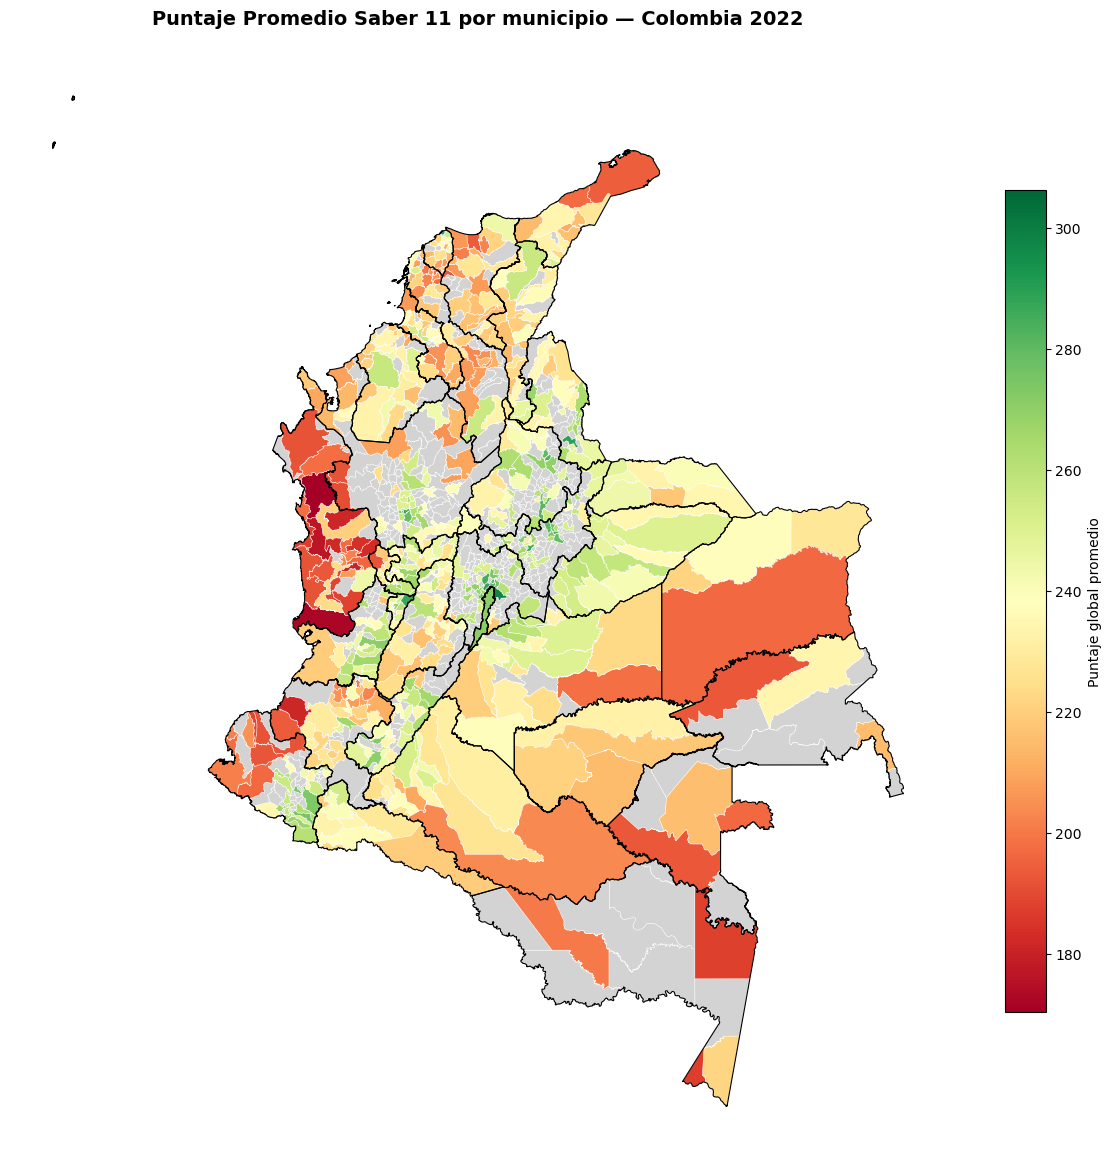

In [101]:
#SUGERENCIA DE IA: Importación de estos paquetes
import matplotlib.pyplot as plt
import seaborn as sns

#Empezamos a construir el mapa por capas:
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Primero, dejamos los municipios sin datos en gris
sf_final[sf_final['punt_global_prom'].isnull()].plot(
    ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3
)

#Luego, los municipios con datos quedarán coloreados por puntaje
#Se incluye título a la leyenda, para identificar que corresponde al puntaje global promedio.
sf_final[sf_final['punt_global_prom'].notna()].plot(
    column='punt_global_prom',
    ax=ax,
    cmap='RdYlGn',
    edgecolor='white',
    linewidth=0.3,
    legend=True,
    legend_kwds={'label': 'Puntaje global promedio', 'shrink': 0.6}
)

#Aprovechando el shapefile departamental, incluimos un borde departamental para identificar mejor las regiones del país.
sf_deptos.plot(
    ax=ax, color='none', edgecolor='black', linewidth=0.8
)

#Le colocamos un título general:
ax.set_title('Puntaje Promedio Saber 11 por municipio — Colombia 2022',
             fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()

La gráfica 1 presentada anteriormente muestra un contexto impresionante a tener en cuenta. En primer lugar, confirma lo que la literatura expresa respecto a la gran desigualdad educativa que tiene Colombia. Por ejemplo, Burbano expresa que Colombia tiene "pronunciadas desigualdades e inequidades sociales y económicas, a pesar de los esfuerzos realizados" (2021, p. 92). En cierta medida, este gráfico muestra que la periferia tiene peores resultados académicos en las Pruebas Saber 11 y, aunque no es una medida del todo precisa para medir educación, es una aproximación lo suficientemente consistente para mostrar que el problema, plenamente identificado, se sigue presentando hasta la segunda mitad del siglo.

Además, es importante notar que, reconociendo que el puntaje máximo es de 500 puntos en estas pruebas, no hay ninguna región del país que tenga un puntaje generalmente alto, ni siquiera las principales capitales. Aunque es verdad que estas capitales muestran mejores rendimientos (todas en la región Andina del país), los resultados de estos estudiantes no son excepcionalmente altos, sino que también tienden a ir hacia el promedio nacional.

Esto, al final, nos muestra que sí hay serias diferencias entre los municipios, y que detrás pueden haber características que, con política pública, podrían atacarse.

#### 4.2. Figura 2. Tabla por Áreas

Otra de las razones por las cuales pueden haber disparidades se puede encontrar en las áreas del conocimiento que se evaluaron. Sabemos que el ICFES evalúa 5 áreas principales:
1. Matemáticas.
2. Lectura.
3. Ciencias Naturales.
4. Sociales y Ciudadanas.
5. Inglés.

Por ello, vamos a crear una pequeña tabla que nos muestre de forma general el promedio de los puntajes clasificados por áreas. Así, podríamos identificar si hay un área en específico que tenga peores resultados. A continuación se observa la figura 2:

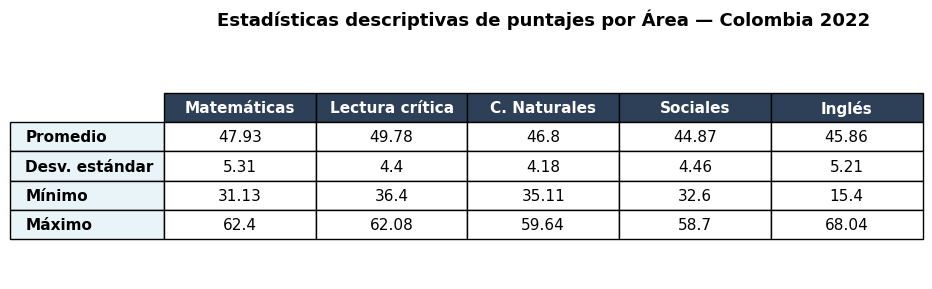

In [104]:
#Por facilidad, vamos a crear una lista con los nombres de las variables que contienen estas áreas:
areas = ['punt_mate_prom', 'punt_lect_prom', 'punt_nat_prom', 
         'punt_soc_prom', 'punt_ingles_prom']

#Creamos las estadísticas descriptivas:
tabla_areas = df_modelo[areas].agg(['mean', 'std', 'min', 'max']).round(2)

#Creamos los títulos para que se vea bien:
tabla_areas.index = ['Promedio', 'Desv. estándar', 'Mínimo', 'Máximo']
tabla_areas.columns = ['Matemáticas', 'Lectura crítica', 
                       'C. Naturales', 'Sociales', 'Inglés']


#SUGERENCIA DE IA: Crear las tablas usando el paquete de figuras.
#Desventaja: Nos da la tabla como una imagen, no como una tabla autocontenida.
fig, ax = plt.subplots(figsize=(10, 3))

#Se eliminan los ejes de la figura ya que construimos una tabla.
ax.axis('off')

tabla_plot = ax.table(
    cellText=tabla_areas.values,
    rowLabels=tabla_areas.index,
    colLabels=tabla_areas.columns,
    cellLoc='center',
    loc='center'
)

tabla_plot.auto_set_font_size(False)
tabla_plot.set_fontsize(11)
tabla_plot.scale(1.3, 1.8)

#Vamos a colocarle un coloreado a los encabezados de las columnas
for j in range(len(tabla_areas.columns)):
    tabla_plot[0, j].set_facecolor('#2E4057')
    tabla_plot[0, j].set_text_props(color='white', fontweight='bold')

#Repetimos el proceso con los encabezados de las filas
for i in range(len(tabla_areas.index)):
    tabla_plot[i+1, -1].set_facecolor('#E8F4F8')
    tabla_plot[i+1, -1].set_text_props(fontweight='bold')

ax.set_title('Estadísticas descriptivas de puntajes por Área — Colombia 2022',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

La tabla de la figura 2 nos da una imagen mucho más clara del análisis respecto a las áreas económicas. Se puede observar que, en promedio, todas las áreas tienen un puntaje alrededor de los 50 puntos, sin que hayan diferencias notables entre ellas. Eso quiere decir que, en nuestra búsqueda de las razones detrás, una idea de currículum diferenciado no podría explicarlo ya que el conocimiento a lo largo de todas las áreas es similar. Bajo, pero similar. Así pues, debemos buscar más allá de la educación y por eso fue que nació la pregunta problema de esta investigación.

#### 4.3. Figura 3: Promedios de Servicios Públicos
Dado que ya revisamos de forma preliminar los resultados por áreas del conocimiento, sería coherente revisar otras áreas relacionadas con la vida y el bienestar de los estudiantes. En esas características podrían encontrarse las diferencias que explica eso que vimos en la figura 1. Por ello, vamos a crear la figura 3 donde se puede ver el promedio de acceso a los municipios a agua potable, a alcantarillado y a energía eléctrica:

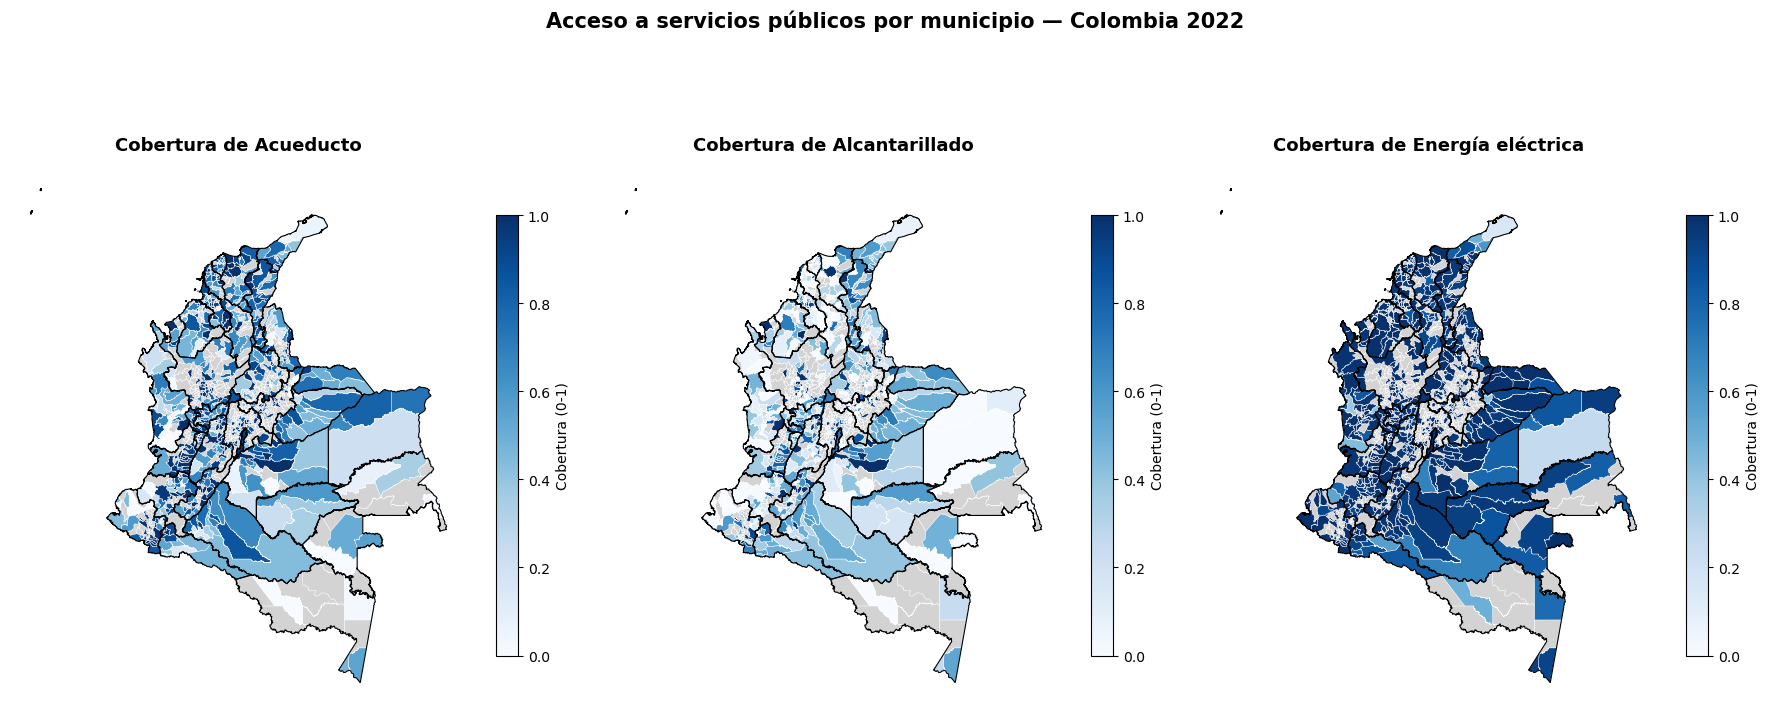

In [124]:
#SUGERENCIA DE IA: Hacer un mapa en conjunto con los tres servicios públicos:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

servicios = {
    'pct_acueducto'     : 'Acueducto',
    'pct_alcantarillado': 'Alcantarillado',
    'pct_energia'       : 'Energía eléctrica'
}

for ax, (col, titulo) in zip(axes, servicios.items()):
    
    # Municipios sin datos en gris
    sf_final[sf_final[col].isnull()].plot(
        ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3
    )
    
    # Municipios con datos coloreados por cobertura
    sf_final[sf_final[col].notna()].plot(
        column=col,
        ax=ax,
        cmap='Blues',
        edgecolor='white',
        linewidth=0.3,
        legend=True,
        vmin=0, vmax=1,
        legend_kwds={'label': 'Cobertura (0-1)', 'shrink': 0.6}
    )
    
    # Bordes departamentales
    sf_deptos.plot(
        ax=ax, color='none', edgecolor='black', linewidth=0.8
    )
    
    ax.set_title(f'Cobertura de {titulo}', fontsize=13, fontweight='bold', pad=10)
    ax.set_axis_off()

fig.suptitle('Acceso a servicios públicos por municipio — Colombia 2022',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

El resultado es consistente con la intuición y la literatura económica. Como se puede observar, la zona Andina del país es la región que cuenta con mayor cobertura de servicios públicos en general. Siendo Bogotá una zona con nivel casi universal. Aun así, es importante denotar las diferencias que se encuentran entre los servicios públicos ya que hay casi una universalidad en la cobertura de energía eléctrica, mientras que el acceso al líquido vital es más restringido en ciertas zonas periféricas del país. Lo anterior va en línea con las observaciones ya realizadas por Parra (2011), donde menciona que la cobertura de energía eléctrica, especialmente en zonas rurales, fue creciendo de manera significativa entre 1997 y 2008 (p. 13). Además, muestra que la cobertura de acueducto no tuvo el mismo rendimiento durante el período, posiblemente por el desplazamiento del campo a las ciudades y por los retos adicionales que implica generar infraestructura de acueducto para transportar el agua desde sitios más lejanos (Parra, 2011, p. 15).

#### 4.4. Figura 4: Resultados del Modelo Regresión Lineal Múltiple

Es por las razones anteriores que decidimos hacer el modelo ya que se pueden encontrar diferencias significativas por fuera del ámbito educativo que sí pueden estar afectando, y fuertemente, a la educación en Colombia. El modelo fue ejecutado anteriormente y sus resultados los podemos encontrar a continuación, en la figura 4. A partir de los resultados de la tabla, repetiremos el mismo ejercicio de la tabla anterior, creando una figura personalizada:

In [120]:
#Primero, volvemos a ejecutar la regresión
modelo, metricas, coeficientes = est_reg_mult(
    X_train_scaled, X_test_scaled, y_train, y_test
)

# Ahora, antes de personalizar la tabla hay que construirla por fuera:
tabla_regresion = coeficientes.copy()
tabla_regresion.columns = ['Variable', 'Coeficiente']

#Creamos un vector con los nombres acomodados de las variables y etiquetamos las variables
nombres = {
    'pct_internet'       : '% Internet',
    'pct_computador'     : '% Computador',
    'pct_educ_madre_sup' : '% Educ. superior madre',
    'pct_educ_padre_sup' : '% Educ. superior padre',
    'pct_sit_eco_mejor'  : '% Situación económica mejor',
    'pct_acueducto'      : '% Acueducto',
    'pct_alcantarillado' : '% Alcantarillado',
    'pct_energia'        : '% Energía eléctrica',
    'tasa_ocupacion'     : 'Tasa de ocupación'
}

tabla_regresion['Variable'] = tabla_regresion['Variable'].map(nombres)

#Vamos a agregar las filas del intercepto, el R2 y el MSE:
tabla_regresion = pd.concat([
    pd.DataFrame({'Variable': ['Intercepto'], 'Coeficiente': [metricas['Intercepto']]}),
    tabla_regresion,
    pd.DataFrame({'Variable': ['R²'],   'Coeficiente': [metricas['R2']]}),
    pd.DataFrame({'Variable': ['RMSE'], 'Coeficiente': [metricas['RMSE']]})
], ignore_index=True)



A partir del código anterior, pudimos crear una tabla que tenga los nombres de las variables mejor acomodados, que incluya toda la información (el intercepto, el $R^2$ y el MSE). Sin embargo, no exporta una tabla diseñada. Por ello, recurrimos de nuevo a crear la figura de la tabla, como se ve a continuación:

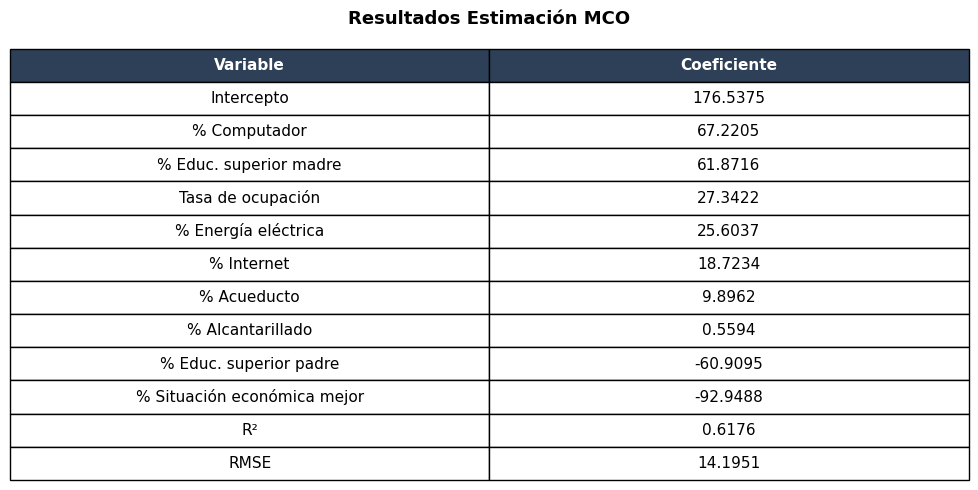

In [123]:
#Empezamos definiendo la figura.
fig, ax = plt.subplots(figsize=(10, 5))

#Eliminamos los ejes porque creamos una tabla, no un gráfico.
ax.axis('off')

# Redondeamos los coeficientes a 4 decimales.
tabla_plot_reg = tabla_regresion.copy()
tabla_plot_reg['Coeficiente'] = tabla_plot_reg['Coeficiente'].round(4)

tabla_mat = ax.table(
    cellText=tabla_plot_reg.values,
    colLabels=tabla_plot_reg.columns,
    cellLoc='center',
    loc='center'
)

tabla_mat.auto_set_font_size(False)
tabla_mat.set_fontsize(11)
tabla_mat.scale(1.3, 1.8)

#Mantenemos distinción de los encabezados coloreándolos.
for j in range(len(tabla_plot_reg.columns)):
    tabla_mat[0, j].set_facecolor('#2E4057')
    tabla_mat[0, j].set_text_props(color='white', fontweight='bold')

#Le colocamos título a la tabla
ax.set_title('Resultados Estimación MCO',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

El resultado es muy importante. En primer lugar, se puede observar que, de base, en el país se obtiene un puntaje en promedio de 176 puntos, lo cual es muy bajo teniendo en cuenta que el rango está entre 0 y 500 puntos. Ahora bien, revisando los coeficientes, el modelo da un $R^2$ considerable de 0,61, indicando que las variables aquí incluidas tienen cierto poder de predicción sobre el puntaje promedio global.

En los indicadores que más se destacan, la presencia de computador en el hogar puede afectar directamente los resultados en el municipio. Un aumento de 1 punto porcentual en el porcentaje de estudiantes que tienen computador en su casa podría aumentar en 67 puntos el promedio del puntaje en el municipio. Por otro lado, el papel y la educación de la mujer en el hogar parece resultar fundamental, muy por encima del efecto de la educación del hombre. Un aumento en 1 punto porcentual de los hogares donde la madre tiene educación superior completa aumenta en casi 61 puntos el puntaje promedio en las pruebas Saber 11.

Por otro lado, es de notar que los servicios públicos tienen un efecto positivo sobre el puntaje también, aunque en menor medida que las variables anteriormente mencionadas. Esto implica que un estudiante necesita de condiciones adecuadas para poder concentrarse, estudiar, desarrollar su potencial y obtener mejores puntuaciones en las pruebas. Por otro lado, también hay que mencionar que hay variables que cargan con un efecto muy negativo y que son interesantes para investigar a largo plazo. Por ejemplo, el efecto de la educación del padre resulta ser muy negativo, a la par que la situación dentro del hogar. En parte, este efecto podría entenderse que, si los estudiantes se ven protegidos por esa figura de autoridad como la paterna y ven una mejor situación en sus hogares, tendrían menos incentivos a tener buenos resultados en el Saber 11, aí que por eso podrían tener peores resultados. Sin embargo, esta parte necesita una parte más exhaustiva de investigación.

### Bibliografía:
Burbano, P. (2021). Pruebas Saber 11: el baremo de la desigualdad educativa en Colombia. HOLOPRAXIS. Revista de Ciencia, Tecnología e Innovación, 5(1), 091-108.

Parra, M. (2011). Infraestructura y pobreza: el caso de los servicios públicos en Colombia. Working Papers Fedesarrollo, 56. Obtenido de: https://www.repository.fedesarrollo.org.co/handle/11445/239



####